In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from simulate_population import sim_population


In [85]:
from Class_definitions import simplecox, CoxNN, cox_partial_loglik, prepare_data_for_cox, MultiCoxNN 
from Class_definitions import  MultiCoxNN, prepare_data_for_multicox, train_coxmulti
from Class_definitions import DiscreteTimeNN, prepare_data_for_event,MultiDiscreteTimeNN, prepare_data_for_multibinary, train_binmulti, get_cindex_multibinary
from Class_definitions import SimpleBinaryTimeSeries, train_simple_timeseries,prepare_data_simple_timeseries,get_cindex_simple_timeseries

In [86]:
import importlib, sys
# Force reload the module
importlib.reload(sys.modules['Class_definitions'])
# Now import again


<module 'Class_definitions' from '/Users/k1514174/Documents/GitHub/medicaljourneys/Class_definitions.py'>

In [87]:
# ============================================================================
# HYPERPARAMETERS (matching Simple_Cox_with_NN-Copy1)
# ============================================================================
BATCH_SIZE = 512
EPOCHS = 300
HIDDEN_LAYERS_COX = (16, 16)
HIDDEN_LAYERS_MULTIBINARY = (32, 32)
HIDDEN_LAYERS_SIMPLE_TIME_SERIES = (32, 32)
STEP_FORWARD = 2
N_STEPS = 5
N_INTERVALS = 50
COVARIATE_COLS = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"]
EVENT_TYPES = ["a", "b", "c", "d", "e"]

In [89]:
# ============================================================================
# PART A: Generate Data
# ============================================================================
print("=" * 80)
print("PART A: Generating Simulation Data")
print("=" * 80)
# Set random seed for reproducibility
np.random.seed(420)
torch.manual_seed(420)

# Generate population with 5 steps forward, step_forward=2
population = sim_population(N=20000, step_forward=STEP_FORWARD, randomseed=420+15)
for i in range(N_STEPS):
    population.step()
    print(f"Step {i+1}/{N_STEPS} completed")

# Get Cox format data (train/test split)
df_cox = population.to_cox_format()
print(f"\nCox format data shape: {df_cox.shape}")
print(f"Columns: {df_cox.columns.tolist()[:15]}...")

# 80/20 train/test split
n_train = int(0.8 * len(df_cox))
df_short = df_cox.iloc[:n_train].reset_index(drop=True)
df_test = df_cox.iloc[n_train:].reset_index(drop=True)

print(f"\nTrain set: {len(df_short)} samples")
print(f"Test set: {len(df_test)} samples")

PART A: Generating Simulation Data
Step 1/5 completed
Step 2/5 completed
Step 3/5 completed
Step 4/5 completed
Step 5/5 completed

Cox format data shape: (20000, 18)
Columns: ['id', 'age_start', 'bmi', 'hyp', 'smoke', 'sex', 'eth1', 'eth2', 'event_a', 'time_a', 'event_b', 'time_b', 'event_c', 'time_c', 'event_d']...

Train set: 16000 samples
Test set: 4000 samples


In [90]:
# ============================================================================
# PART A2: Long format data for binary classification time-series model
# ============================================================================
# --- Prepare long-format data, filtered to train patient IDs ---
train_ids   = set(df_short["id"].values)
df_long_all = prepare_data_simple_timeseries(population)

df_long_train = df_long_all[df_long_all["id"].isin(train_ids)].reset_index(drop=True)
df_long_test = df_long_all[ df_long_all["id"].isin(train_ids)== False].reset_index(drop=True)
print(f"  Long-format train rows: {len(df_long_train)}  "
          f"({df_long_train['interval'].nunique()} intervals, "
          f"{df_long_train['id'].nunique()} patients)")

  Long-format train rows: 96000  (6 intervals, 16000 patients)


In [91]:
# ============================================================================
# PART B & C: Initialize & Train Models
# ============================================================================
print("\n" + "=" * 80)
print("PART B & C: Training Models")
print("=" * 80)

models = {}
cindex_results = {}

# -------- 1. Lifelines Cox (Baseline) --------
print("\n[1/5] Training Lifelines Cox Model...")
models['lifelines_cox'] = {}
for event in EVENT_TYPES:
    print(f"  → Event {event}...", end=" ")
    cph = CoxPHFitter()
    time_col = f"time_{event}"
    event_col = f"event_{event}"
    cph.fit(df_short[[time_col, event_col] + COVARIATE_COLS], 
            duration_col=time_col, event_col=event_col)
    models['lifelines_cox'][event] = cph
    print("done")

# -------- 2. Multi-Outcome Cox (NO Hidden Layers) --------
print("\n[2/5] Training Multi-Outcome Cox (No Hidden Layers)...")
x2_train, time2_train, event2_train = prepare_data_for_multicox(
    df_short, 
    covariate_cols=COVARIATE_COLS,
    time_cols=[f"time_{e}" for e in EVENT_TYPES],
    event_cols=[f"event_{e}" for e in EVENT_TYPES]
)
models['multicox_no_hidden'] = train_coxmulti(
    x2_train, time2_train, event2_train, 
    hidden_dims=(), epochs=EPOCHS, K=5
)
print("done")

# -------- 3. Multi-Outcome Cox (WITH Hidden Layers) --------
print("\n[3/5] Training Multi-Outcome Cox (With Hidden Layers)...")
models['multicox_with_hidden'] = train_coxmulti(
    x2_train, time2_train, event2_train, 
    hidden_dims=HIDDEN_LAYERS_COX, epochs=EPOCHS, K=5
)
print("done")

# -------- 4. Multi-Binary (NO Hidden Layers) --------
print("\n[4/5] Training Multi-Binary Model (No Hidden Layers)...")
X_train, intervals_train, events_train, n_intervals = prepare_data_for_multibinary(
    df_short, 
    features=COVARIATE_COLS,
    event_types=EVENT_TYPES,
    n_intervals=N_INTERVALS,
    even_split=True  # Use time split every 2 years
)
models['multibinary_no_hidden'] = train_binmulti(
    X_train, intervals_train, events_train, n_intervals,
    hidden_dims=(), lr=0.01, epochs=EPOCHS, batch_size=BATCH_SIZE
)
print("done")

# -------- 5. Multi-Binary (WITH Hidden Layers) --------
print("\n[5/5] Training Multi-Binary Model (With Hidden Layers)...")
models['multibinary_with_hidden'] = train_binmulti(
    X_train, intervals_train, events_train, n_intervals,
    hidden_dims=HIDDEN_LAYERS_MULTIBINARY, lr=0.001, epochs=EPOCHS+100, batch_size=BATCH_SIZE*2
)
print("done")




PART B & C: Training Models

[1/5] Training Lifelines Cox Model...
  → Event a... done
  → Event b... done
  → Event c... done
  → Event d... done
  → Event e... done

[2/5] Training Multi-Outcome Cox (No Hidden Layers)...
Epoch 0, loss = 111225.2031
Epoch 50, loss = 85340.8125
Epoch 100, loss = 84975.4219
Epoch 150, loss = 84888.2656
Epoch 200, loss = 84865.2109
Epoch 250, loss = 84860.3281
Epoch 299, loss = 84859.5625
done

[3/5] Training Multi-Outcome Cox (With Hidden Layers)...
Epoch 0, loss = 89907.9453
Epoch 50, loss = 85137.5156
Epoch 100, loss = 84376.0156
Epoch 150, loss = 84230.6484
Epoch 200, loss = 84189.7734
Epoch 250, loss = 84177.8516
Epoch 299, loss = 84172.8594
done

[4/5] Training Multi-Binary Model (No Hidden Layers)...
Epoch 1/300, Loss: 2.2945
Epoch 51/300, Loss: 0.0321
Epoch 101/300, Loss: 0.0285
Epoch 151/300, Loss: 0.0279
Epoch 201/300, Loss: 0.0277
Epoch 251/300, Loss: 0.0277
Epoch 300/300, Loss: 0.0276
done

[5/5] Training Multi-Binary Model (With Hidden Laye

In [101]:
# -------- 6. Simple Time Series - LINEAR  --------
print("\n[6/7] Training Simple Time Series Model (Linear, No Hidden Layers)...")
models['simple_time_series_linear'] = train_simple_timeseries(
        df_long_train,
        features=COVARIATE_COLS,
        event_types=EVENT_TYPES,
        hidden_dims=(),
        lr=0.01,
        epochs=10,
        batch_size=BATCH_SIZE,
    )
print("done")

# -------- 7. Simple Time Series  --------
print("\n[7/7] Training Simple Time Series Model (With Hidden Layers)...")
models['simple_t_series'] = train_simple_timeseries(
        df_long_train,
        features=COVARIATE_COLS,
        event_types=EVENT_TYPES,
        hidden_dims=(32,32) ,
        lr=0.001,
        epochs=100,
        batch_size=BATCH_SIZE,
    )
   
print("done")


[6/7] Training Simple Time Series Model (Linear, No Hidden Layers)...
Epoch 1/10  loss = 0.4033
Epoch 10/10  loss = 0.3402
done

[7/7] Training Simple Time Series Model (With Hidden Layers)...
Epoch 1/100  loss = 0.4202
Epoch 51/100  loss = 0.3260
Epoch 100/100  loss = 0.3253
done


In [102]:
# ============================================================================
# PART D: Extract Beta Coefficients
# ============================================================================
print("\n" + "=" * 80)
print("PART D: Extracting Beta Coefficients")
print("=" * 80)

beta_df_list = []

# Lifelines Cox - extract coefficients
print("\nExtracting coefficients from Lifelines Cox...")
for event in EVENT_TYPES:
    cph = models['lifelines_cox'][event]
    for covariate in COVARIATE_COLS:
        beta_df_list.append({
            'Model': 'Lifelines Cox',
            'Event': event,
            'Covariate': covariate,
            'Beta': cph.params_[covariate]
        })

# Multi-Outcome Cox (No Hidden Layers) - extract coefficients
print("Extracting coefficients from Multi-Outcome Cox (No Hidden Layers)...")
model_multicox_no_hidden = models['multicox_no_hidden']
with torch.no_grad():
    # The final linear layer maps to K outcomes
    final_layer_weight = model_multicox_no_hidden.net[-1].weight  # (K, p)
    for k, event in enumerate(EVENT_TYPES):
        for i, covariate in enumerate(COVARIATE_COLS):
            beta_df_list.append({
                'Model': 'MultiCox Linear',
                'Event': event,
                'Covariate': covariate,
                'Beta': final_layer_weight[k, i].item()
            })

# Multi-Binary (No Hidden Layers) - extract coefficients
print("Extracting coefficients from Multi-Binary (No Hidden Layers)...")
model_multibinary_no_hidden = models['multibinary_no_hidden']
with torch.no_grad():
    # The final linear layer maps to K outcomes
    final_layer_weight = model_multibinary_no_hidden.net[-1].weight  # (K, p)
    for k, event in enumerate(EVENT_TYPES):
        for i, covariate in enumerate(COVARIATE_COLS):
            beta_df_list.append({
                'Model': 'MultiBinary Linear',
                'Event': event,
                'Covariate': covariate,
                'Beta': final_layer_weight[k, i].item()
            })

# Simple Time Series (No Hidden Layers) - extract coefficients
print("Extracting coefficients from Simple Time Series (No Hidden Layers)...")
model_sts_linear = models['simple_time_series_linear']
betas = model_sts_linear.get_beta()  # (K, p)
for k, event in enumerate(EVENT_TYPES):
    for i, covariate in enumerate(COVARIATE_COLS):
        beta_df_list.append({
            'Model': 'SimpleTimeSeries Linear',
            'Event': event,
            'Covariate': covariate,
            'Beta': betas[k, i]
        })

beta_comparison_df = pd.DataFrame(beta_df_list)
print(f"\nTotal coefficients extracted: {len(beta_comparison_df)}")

# Reshape beta_comparison_df to have Model as columns, with Event as an additional column
beta_comparison_df = beta_comparison_df.pivot_table( index=['Event', 'Covariate'],columns='Model',values='Beta').reset_index()



PART D: Extracting Beta Coefficients

Extracting coefficients from Lifelines Cox...
Extracting coefficients from Multi-Outcome Cox (No Hidden Layers)...
Extracting coefficients from Multi-Binary (No Hidden Layers)...
Extracting coefficients from Simple Time Series (No Hidden Layers)...

Total coefficients extracted: 140


In [103]:
# ============================================================================
# PART E: Compute C-Index for All Models
# ============================================================================
print("\n" + "=" * 80)
print("PART E: Computing C-Index for All Models")
print("=" * 80)
cindex_df_list = []

# Prepare test data
x2_test, time2_test, event2_test = prepare_data_for_multicox(
    df_test, 
    covariate_cols=COVARIATE_COLS,  time_cols=[f"time_{e}" for e in EVENT_TYPES], 
    event_cols=[f"event_{e}" for e in EVENT_TYPES])
X_test, intervals_test, events_test, _ = prepare_data_for_multibinary(
    df_test,
    features=COVARIATE_COLS,  event_types=EVENT_TYPES,  n_intervals=N_INTERVALS,  even_split=True)

# -------- 1. Lifelines Cox C-Index --------
print("\n 1 Computing C-Index for Lifelines Cox...")
for event in EVENT_TYPES:
    cph = models['lifelines_cox'][event]
    time_col = f"time_{event}"
    event_col = f"event_{event}"
    predictions = cph.predict_partial_hazard(df_test[COVARIATE_COLS])
    c_index = concordance_index(df_test[time_col].values, 1- predictions.values,df_test[event_col].values)
    cindex_df_list.append({'Model': 'Lifelines Cox','Event': event,'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 2. Multi-Outcome Cox (No Hidden Layers) C-Index --------
print("\n2 Computing C-Index for Multi-Outcome Cox (No Hidden Layers)...")
with torch.no_grad(): eta_test = models['multicox_no_hidden'](x2_test)
for k, event in enumerate(EVENT_TYPES):
    c_index = concordance_index(df_test[f"time_{event}"].values,-eta_test[:, k].numpy(), df_test[f"event_{event}"].values)
    cindex_df_list.append({ 'Model': 'MultiCox Linear',  'Event': event, 'C-Index': c_index })
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 3. Multi-Outcome Cox (With Hidden Layers) C-Index --------
print("\n3 Computing C-Index for Multi-Outcome Cox (With Hidden Layers)...")
with torch.no_grad():
    eta_test = models['multicox_with_hidden'](x2_test)
for k, event in enumerate(EVENT_TYPES):
    c_index = concordance_index(df_test[f"time_{event}"].values, -eta_test[:, k].numpy(), df_test[f"event_{event}"].values)
    cindex_df_list.append({'Model': 'MultiCox Hidden', 'Event': event,'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 4. Multi-Binary (No Hidden Layers) C-Index --------
print("\n4 Computing C-Index for Multi-Binary (No Hidden Layers)...")
with torch.no_grad():
    eta_test = models['multibinary_no_hidden'].get_eta(torch.FloatTensor(X_test)).numpy()
for k, event in enumerate(EVENT_TYPES):
    c_index = concordance_index( df_test[f"time_{event}"].values,-eta_test[:, k], df_test[f"event_{event}"].values)
    cindex_df_list.append({'Model': 'MultiBinary Linear', 'Event': event, 'C-Index': c_index })
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 5. Multi-Binary (With Hidden Layers) C-Index --------
print("\n5 Computing C-Index for Multi-Binary (With Hidden Layers)...")
with torch.no_grad():
    eta_test = models['multibinary_with_hidden'].get_eta(torch.FloatTensor(X_test)).numpy()
for k, event in enumerate(EVENT_TYPES):
    c_index = concordance_index( df_test[f"time_{event}"].values, -eta_test[:, k], df_test[f"event_{event}"].values)
    cindex_df_list.append({ 'Model': 'MultiBinary Hidden','Event': event,'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 6. Simple Time Series Linear C-Index --------
print("\n6 Computing C-Index for Simple Time Series (Linear)...")
for k, event in enumerate(EVENT_TYPES):
    with torch.no_grad():
        eta_test = models['simple_time_series_linear'].get_eta(
            torch.FloatTensor(df_test[COVARIATE_COLS].values)
        ).numpy()
    c_index = concordance_index(df_test[f"time_{event}"].values,
                                -eta_test[:, k],
                                df_test[f"event_{event}"].values)
    cindex_df_list.append({'Model': 'SimpleTimeSeries Linear', 'Event': event, 'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 7. Simple Time Series With Hidden Layers C-Index --------
print("\n7 Computing C-Index for Simple Time Series (With Hidden Layers)...")
eta_test = None  # recompute
for k, event in enumerate(EVENT_TYPES):
    with torch.no_grad():
        eta_test = models['simple_t_series'].get_eta(
            torch.FloatTensor(df_test[COVARIATE_COLS].values)
        ).numpy()
    c_index = concordance_index(df_test[f"time_{event}"].values,
                                -eta_test[:, k],
                                df_test[f"event_{event}"].values)
    cindex_df_list.append({'Model': 'SimpleTimeSeries Hidden', 'Event': event, 'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

cindex_df = pd.DataFrame(cindex_df_list)



PART E: Computing C-Index for All Models

 1 Computing C-Index for Lifelines Cox...
  Event a: C-Index = 0.7224
  Event b: C-Index = 0.6564
  Event c: C-Index = 0.6324
  Event d: C-Index = 0.6151
  Event e: C-Index = 0.6295

2 Computing C-Index for Multi-Outcome Cox (No Hidden Layers)...
  Event a: C-Index = 0.7224
  Event b: C-Index = 0.6564
  Event c: C-Index = 0.6324
  Event d: C-Index = 0.6151
  Event e: C-Index = 0.6295

3 Computing C-Index for Multi-Outcome Cox (With Hidden Layers)...
  Event a: C-Index = 0.7225
  Event b: C-Index = 0.7115
  Event c: C-Index = 0.6994
  Event d: C-Index = 0.6158
  Event e: C-Index = 0.6433

4 Computing C-Index for Multi-Binary (No Hidden Layers)...
  Event a: C-Index = 0.7213
  Event b: C-Index = 0.6337
  Event c: C-Index = 0.6056
  Event d: C-Index = 0.5657
  Event e: C-Index = 0.6232

5 Computing C-Index for Multi-Binary (With Hidden Layers)...
  Event a: C-Index = 0.7220
  Event b: C-Index = 0.7075
  Event c: C-Index = 0.6998
  Event d: C-Inde

In [104]:
# ============================================================================
# SUMMARY RESULTS
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY RESULTS")
print("=" * 80)
print("### C-Index Comparison by Event ###")
cindex_pivot = cindex_df.pivot(index='Model', columns='Event', values='C-Index').round(4).T
cindex_pivot

#print("\n### Mean C-Index by Model ###")
#print(cindex_df.groupby('Model')['C-Index'].mean().round(4).sort_values(ascending=False))

# Save results to CSV
#print("\n" + "=" * 80)
#print("Saving Results to CSV...")
#print("=" * 80)
#beta_comparison_df.to_csv('beta_coefficients_comparison.csv', index=False)
#cindex_df.to_csv('cindex_comparison.csv', index=False)
#cindex_pivot.to_csv('cindex_pivot.csv')
#print("✓ Results saved!")


SUMMARY RESULTS
### C-Index Comparison by Event ###


Model,Lifelines Cox,MultiBinary Hidden,MultiBinary Linear,MultiCox Hidden,MultiCox Linear,SimpleTimeSeries Hidden,SimpleTimeSeries Linear
Event,,,,,,,
a,0.7224,0.7220,0.7213,0.7225,0.7224,0.7218,0.7223
b,0.6564,0.7075,0.6337,0.7115,0.6564,0.7218,0.6561
c,0.6324,0.6998,0.6056,0.6994,0.6324,0.7085,0.6318
d,0.6151,0.6112,0.5657,0.6158,0.6151,0.6189,0.6101
e,0.6295,0.6405,0.6232,0.6433,0.6295,0.6460,0.6293


In [105]:
beta_comparison_df.loc[beta_comparison_df.Event=="a", ]

Model,Event,Covariate,Lifelines Cox,MultiBinary Linear,MultiCox Linear,SimpleTimeSeries Linear
0,a,age_start,0.028231,0.033428,0.028154,0.034078
1,a,bmi,0.500461,0.623048,0.498096,0.602129
2,a,eth1,0.492958,0.580241,0.485696,0.579157
3,a,eth2,2.033871,3.994134,2.004213,2.676186
4,a,hyp,0.750185,0.744875,0.747993,0.928393
5,a,sex,0.003903,0.244394,0.003718,-0.002318
6,a,smoke,0.012473,0.046489,0.012627,-0.004284


<Axes: xlabel='Event'>

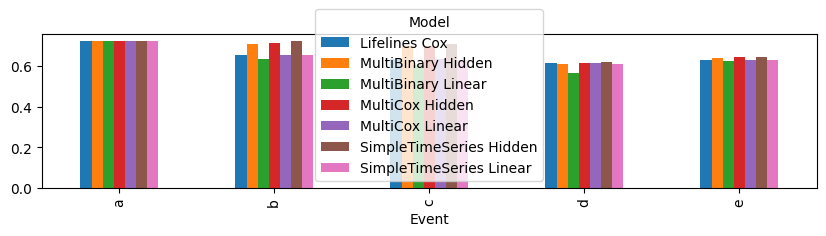

In [106]:
cindex_pivot.plot.bar(figsize = (10,2))